<a href="https://colab.research.google.com/github/rsyadipras/PCVK_Ganjil2026/blob/main/Week5_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week5 — Histogram, Histogram Equalization, dan Dithering**

In [1]:
# ===== SEL IDENTITAS JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Risky Adi Prasetya'
NIM = '244107020153'

N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1)
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N:', N)
for k, v in PARAM.items():
    print(f'{k:<6} : {v}')
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Risky Adi Prasetya
NIM    : 244107020153 | N: 153
bins   : 16
clip   : 2.5
tile   : 3
L      : 2
WAKTU  : 2026-10-03 20:42:24 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 0f68253922684a2d


# **E-1 PERCOBAAN HISTOGRAM**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Konfigurasi Path Folder
CONTOH = '/content/drive/MyDrive/PCVK2026/Images'
BASE = '/content/drive/MyDrive/PCVK2026/Images/244107020153'

Mounted at /content/drive


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

## Langkah 3 - Flowchart

Tahap 1: Lena.jpg, tahap 2: KTM1B.jpeg

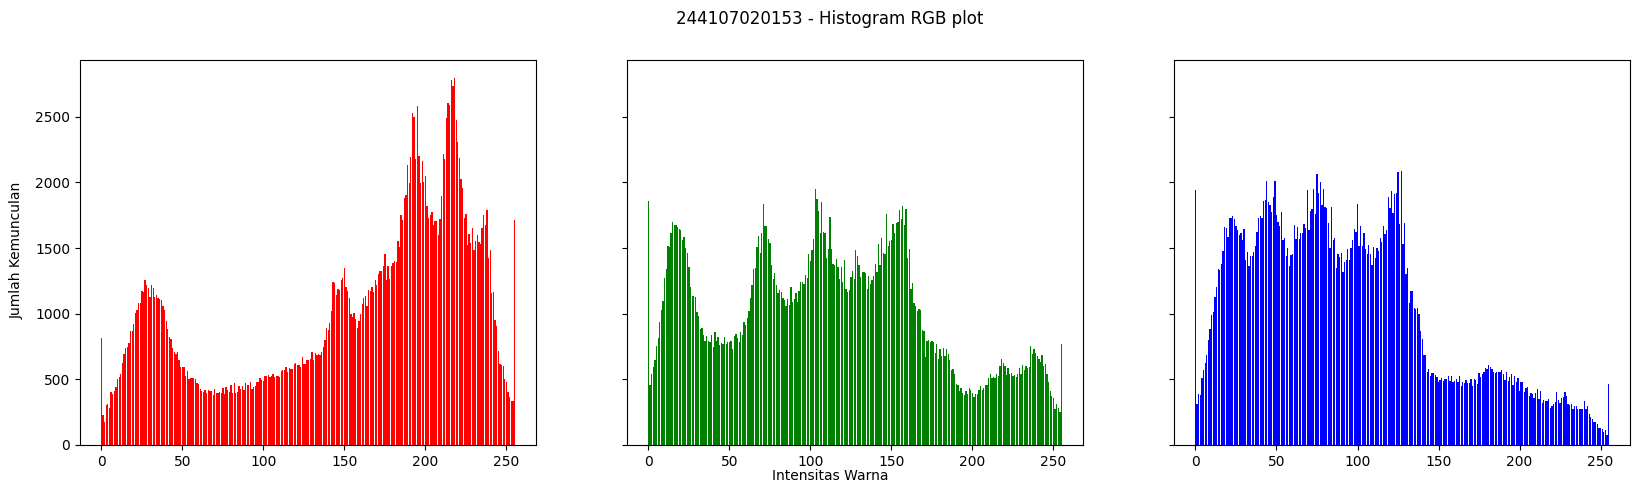

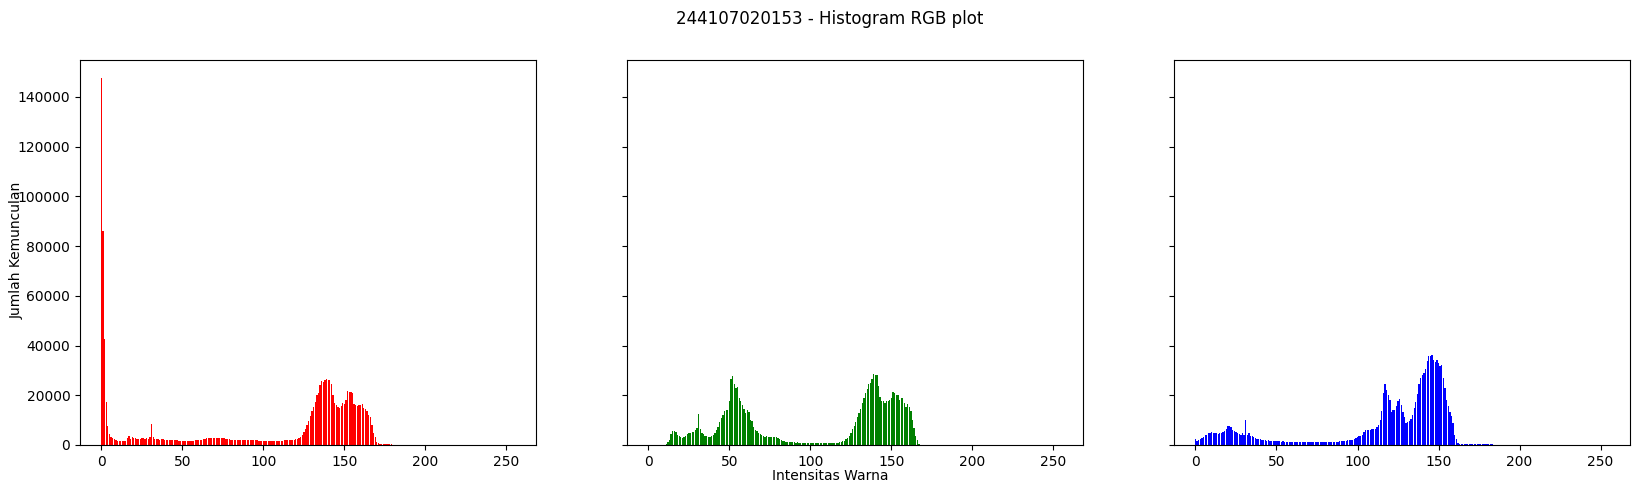

In [4]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)         # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):           # 2. telusuri setiap baris
        for x in range(img.shape[1]):       #    dan setiap kolom
            h[img[y, x]] += 1               # 3. tambah 1 sesuai nilai piksel
    return h


def tampilkan_histogram_rgb(berkas, judul_prefix):
    img = cv.imread(berkas)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    height, width, depth = np.shape(img)
    names = np.arange(256)
    red, green, blue = [0] * 256, [0] * 256, [0] * 256

    for y in range(height):
        for x in range(width):
            red[img[y][x][0]]   += 1
            green[img[y][x][1]] += 1
            blue[img[y][x][2]]  += 1

    fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
    fig.suptitle(judul_prefix + ' - Histogram RGB plot')
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

    axs[0].bar(names, red, color='red')
    axs[1].bar(names, green, color='green')
    axs[2].bar(names, blue, color='blue')
    plt.show()


# Tahap 1: citra contoh
tampilkan_histogram_rgb(CONTOH + '/lena.jpg', NIM)

# Tahap 2: citra KTM
tampilkan_histogram_rgb(BASE + '/KTM1b.jpeg', NIM)

## PERTANYAAN PRAKTIKUM E1

In [5]:
# Soal 1 - histogram_manual vs numpy.histogram vs cv.calcHist
def bandingkan_tiga_metode(berkas, judul):
    gray = cv.imread(berkas, cv.IMREAD_GRAYSCALE)
    h_manual = histogram_manual(gray)
    h_numpy, _ = np.histogram(gray, bins=256, range=(0, 256))
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()

    sel_manual_numpy = np.max(np.abs(h_manual - h_numpy))
    sel_manual_cv    = np.max(np.abs(h_manual - h_cv))

    print(judul)
    print('  selisih maksimum manual vs numpy.histogram :', sel_manual_numpy)
    print('  selisih maksimum manual vs cv.calcHist     :', sel_manual_cv)
    assert sel_manual_numpy == 0 and sel_manual_cv == 0, 'Selisih harus nol!'
    return h_manual, h_numpy, h_cv

_ = bandingkan_tiga_metode(CONTOH + '/lena.jpg', NIM + ' - lena.jpg')
_ = bandingkan_tiga_metode(BASE + '/KTM1b.jpeg', NIM + ' - KTM1b.jpeg')

244107020153 - lena.jpg
  selisih maksimum manual vs numpy.histogram : 0
  selisih maksimum manual vs cv.calcHist     : 0.0
244107020153 - KTM1b.jpeg
  selisih maksimum manual vs numpy.histogram : 0
  selisih maksimum manual vs cv.calcHist     : 0.0


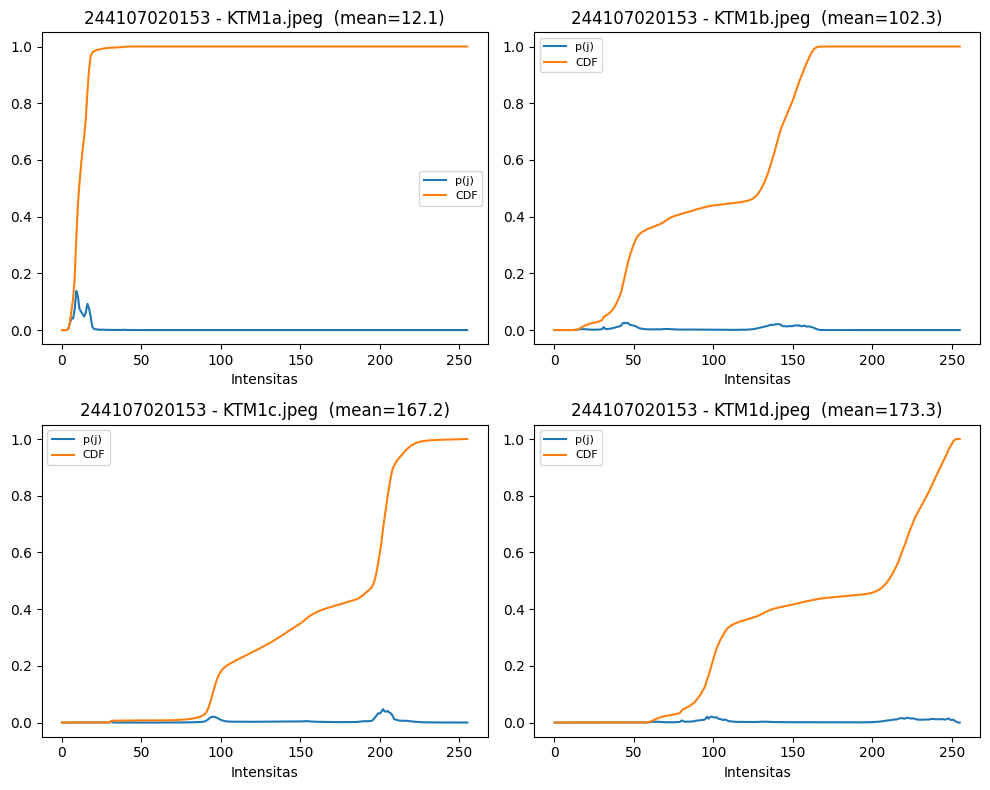

In [6]:
# Soal 2 - histogram ternormalisasi p(j) dan CDF untuk KTM1a–KTM1d (2x2)
ktms = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for ax, f in zip(axs.flat, ktms):
    gray = cv.imread(BASE + '/' + f, cv.IMREAD_GRAYSCALE)
    h = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    p = h / gray.size
    cdf = np.cumsum(p)

    ax.plot(p, label='p(j)')
    ax.plot(cdf, label='CDF')
    ax.set_title(NIM + ' - ' + f + f'  (mean={gray.mean():.1f})')
    ax.set_xlabel('Intensitas')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

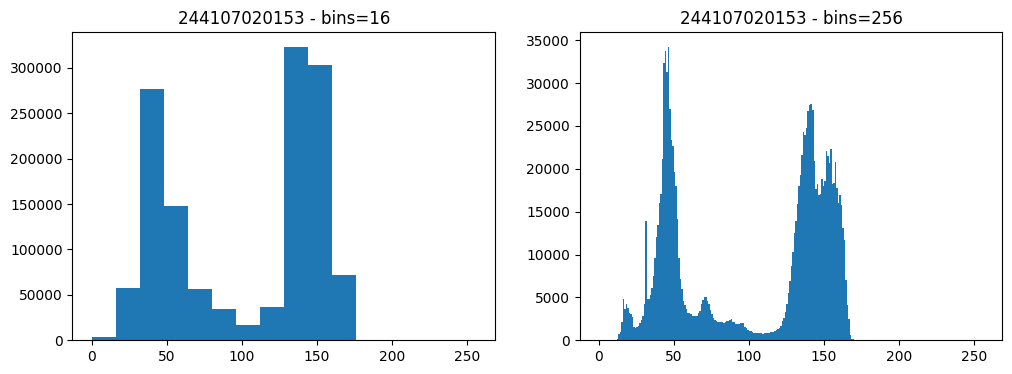

In [7]:
# Soal 3 - histogram KTM1b.jpg dengan bins=PARAM['bins'] vs 256 bin
gray_ktmb = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(gray_ktmb.ravel(), bins=PARAM['bins'], range=(0, 256))
axs[0].set_title(NIM + f" - bins={PARAM['bins']}")

axs[1].hist(gray_ktmb.ravel(), bins=256, range=(0, 256))
axs[1].set_title(NIM + " - bins=256")

plt.show()